In [ ]:
UPLOAD

In [3]:
from google.colab import files
uploaded = files.upload()


Saving catsvsdogs.zip to catsvsdogs.zip


In [4]:
import os

os.listdir()

['.config', 'catsvsdogs.zip', 'sample_data']

In [7]:
print(os.listdir("/content"))

['.config', 'catsvsdogs.zip', 'sample_data']


EXTRACTION

In [8]:
import zipfile

zip_path = "/content/catsvsdogs.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Extraction done")

Extraction done


In [23]:
import os

base = "/content/dataset_fixed"

os.makedirs(base + "/train/cats", exist_ok=True)
os.makedirs(base + "/train/dogs", exist_ok=True)
os.makedirs(base + "/test/cats", exist_ok=True)
os.makedirs(base + "/test/dogs", exist_ok=True)

In [24]:
import os
import shutil

source = "/content/dataset"

for root, dirs, files in os.walk(source):
    for file in files:
        path = os.path.join(root, file)

        # convert windows path to normal
        norm_path = path.replace("\\", "/")

        if "train/cats" in norm_path:
            shutil.copy(path, "/content/dataset_fixed/train/cats/" + file)

        elif "train/dogs" in norm_path:
            shutil.copy(path, "/content/dataset_fixed/train/dogs/" + file)

        elif "test/cats" in norm_path:
            shutil.copy(path, "/content/dataset_fixed/test/cats/" + file)

        elif "test/dogs" in norm_path:
            shutil.copy(path, "/content/dataset_fixed/test/dogs/" + file)

In [42]:
import os

print(len(os.listdir("/content/dataset_fixed/train/cats")))
print(len(os.listdir("/content/dataset_fixed/train/dogs")))
print(len(os.listdir("/content/dataset_fixed/test/cats")))
print(len(os.listdir("/content/dataset_fixed/test/dogs")))

10000
10000
2500
2500


DATA LOADING

In [43]:
import tensorflow as tf

IMG_SIZE = (150,150)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset_fixed/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset_fixed/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


PREPROCESSING

In [44]:
import tensorflow as tf

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [45]:
for images, labels in train_dataset.take(1):
    print("dtype:", images.dtype)
    print("min:", tf.reduce_min(images).numpy())
    print("max:", tf.reduce_max(images).numpy())

dtype: <dtype: 'float32'>
min: 0.0
max: 1.0


VISUALISATION


In [ ]:

import matplotlib.pyplot as plt

class_names = ["cats", "dogs"]

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        img = images[i].numpy()

        plt.subplot(3,3,i+1)
        plt.imshow(img)   # NO scaling at all
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.show()

BUIL CNN MODEL

In [46]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(150,150,3)
    ),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation='sigmoid'
    )
])

In [47]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

COMPILATION

In [48]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

TRAIN MODEL

In [53]:
train_dataset = train_dataset.cache().prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(tf.data.AUTOTUNE)

In [54]:
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=test_dataset
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 925s 1s/step - accuracy: 0.7803 - loss: 0.4684 - val_accuracy: 0.7906 - val_loss: 0.4473
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 925s 1s/step - accuracy: 0.8145 - loss: 0.4086 - val_accuracy: 0.8170 - val_loss: 0.3986
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 925s 1s/step - accuracy: 0.8443 - loss: 0.3542 - val_accuracy: 0.8316 - val_loss: 0.3877
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 920s 1s/step - accuracy: 0.8697 - loss: 0.3050 - val_accuracy: 0.8398 - val_loss: 0.3914
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 921s 1s/step - accuracy: 0.8908 - loss: 0.2559 - val_accuracy: 0.8324 - val_loss: 0.3935


In [ ]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [55]:
loss, accuracy = model.evaluate(test_dataset)

print("Loss:", loss)
print("Accuracy:", accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 442ms/step - accuracy: 0.8324 - loss: 0.3935
Loss: 0.39351606369018555
Accuracy: 0.8324000239372253


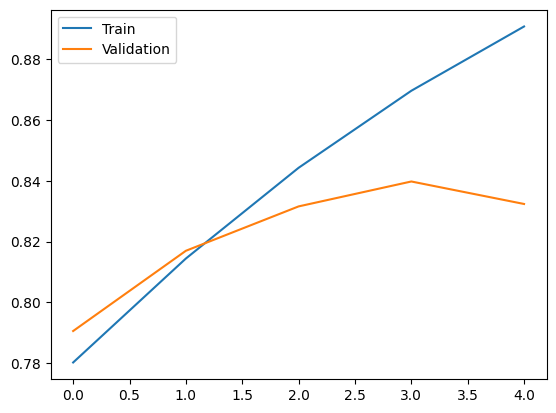

In [56]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.show()

In [57]:
model.save("cats_dogs_cnn.h5")

In [58]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/download.jpg"

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 829ms/step
Dog


In [60]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/download (2).jpg"   # replace with your image path

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Cat
